# Arrumando dados brutos dos dspaces das universidades

In [1]:
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np

import xavy.explore as xe
import xavy.dataframes as xd

## Funções

In [67]:
def group_duplicated(df, subset):
    """
    Return the rows in `df` that have duplicated `subset` 
    of columns. Cluster these duplicated rows together
    in the output.
    """
    return df.loc[df[subset].duplicated(keep=False)].sort_values(by=subset)

## UFAM

In [170]:
def print_teses(teses_df):
    """
    Print title, abstract and keywords for each academic work in DataFrame.
    Expects columns 'titulo', 'resumo' and 'palavras_chave'.
    """
    for i in range(len(teses_df)):
        r = teses_df.iloc[i]
        print(xd.bold(r['titulo_obra']))
        print(r['resumo_obra'])
        print('')
        print('Palavras-chave:', r['palavras_chave'])
        print('')

### RIU

In [9]:
riu_ufam_df = pd.read_excel('../dados/dspaces/brutos/ufam/dados_RIU_UFAM.xlsx')
riu_df      = pd.read_excel('../dados/dspaces/brutos/ufam/dados_RIU.xlsx')

In [17]:
# Verifica se todas as colunas são as mesmas:
(riu_df.columns == riu_ufam_df.columns)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [21]:
xe.checkMissing(riu_df, only_missing=False)

Colunas com valores faltantes:
                     coluna       N      %
0                   autoria    13.0   0.37
1        docente_orientador   127.0   3.66
2               titulo_obra     0.0    0.0
3           data_publicacao   207.0   5.96
4       instituicao_fomento  3439.0  99.02
5   instituicao_publicadora  3462.0  99.68
6             campus_defesa   113.0   3.25
7            programa_curso   113.0   3.25
8             tipo_trabalho     0.0    0.0
9           nivel_academico  3473.0  100.0
10            total_paginas  3473.0  100.0
11              resumo_obra   142.0   4.09
12         idioma_principal     0.0    0.0
13                 uri_link     0.0    0.0
14           palavras_chave    29.0   0.84


In [23]:
xe.checkMissing(riu_ufam_df, only_missing=False)

Colunas com valores faltantes:
                     coluna       N      %
0                   autoria     0.0    0.0
1        docente_orientador    14.0   0.43
2               titulo_obra     0.0    0.0
3           data_publicacao     0.0    0.0
4       instituicao_fomento  3253.0  99.94
5   instituicao_publicadora     0.0    0.0
6             campus_defesa     0.0    0.0
7            programa_curso     0.0    0.0
8             tipo_trabalho     0.0    0.0
9           nivel_academico     0.0    0.0
10            total_paginas  3255.0  100.0
11              resumo_obra     6.0   0.18
12         idioma_principal     0.0    0.0
13                 uri_link     0.0    0.0
14           palavras_chave     0.0    0.0


**Conclusão:** Parece que os dados do RIU UFAM são mais completos que os do RIU.

In [25]:
len(set(riu_df['uri_link']) & set(riu_ufam_df['uri_link']))

3255

In [26]:
len(set(riu_df['titulo_obra']) & set(riu_ufam_df['titulo_obra']))

3250

In [29]:
# URIs do RIU UFAM é subconjunto dos URIs do RIU:
set(riu_ufam_df['uri_link']) - set(riu_df['uri_link'])

set()

In [40]:
riu_ufam_sufixes = ('_ufam', '_riu')
riu_ufam_merge_df = riu_ufam_df.merge(riu_df, on='uri_link', how='inner', suffixes=riu_ufam_sufixes)

In [41]:
riu_ufam_df.columns

Index(['autoria', 'docente_orientador', 'titulo_obra', 'data_publicacao',
       'instituicao_fomento', 'instituicao_publicadora', 'campus_defesa',
       'programa_curso', 'tipo_trabalho', 'nivel_academico', 'total_paginas',
       'resumo_obra', 'idioma_principal', 'uri_link', 'palavras_chave'],
      dtype='str')

In [42]:
def loc_differing_data(merge_df, col, suffixes):
    """
    Return rows in provided DataFrame whose twin columns 
    do not match.

    Parameters
    ----------
    merge_df : DataFrame
        Merge between two tables with the same columns.
    col : DataFrame
        Column name in the tables to check.
    suffixes : tuple, shape (2,)
        Suffixes applied to the two table columns during 
        the merger.

    Returns
    -------
    z : DataFrame
        Rows in merge_df whose columns `col`+ suffixes 
        do not match.
    """
    x = merge_df[col + suffixes[0]]
    y = merge_df[col + suffixes[1]]
    z = merge_df.loc[x != y]
    return z

In [47]:
for col in list(set(riu_df.columns) - {'uri_link'}):
    ddf = loc_differing_data(riu_ufam_merge_df, col, riu_ufam_sufixes)
    if len(ddf) > 0:
        print(xe.bold(col), len(ddf))
        display(ddf[[col + riu_ufam_sufixes[0], col + riu_ufam_sufixes[1]]].drop_duplicates())

campus_defesa 4


,campus_defesa_ufam,campus_defesa_riu
2389,Must University,NaN
2394,Must University,Departamento de Educação


docente_orientador 14


,docente_orientador_ufam,docente_orientador_riu
128,NaN,NaN


nivel_academico 3255


...

,total_paginas_ufam,total_paginas_riu
0,NaN,NaN


instituicao_publicadora 3255


,instituicao_publicadora_ufam,instituicao_publicadora_riu
0,Universidade Federal do Amazonas,NaN
1329,Universidade de Coimbra,NaN
2365,MUST University,NaN
2389,Must University,NaN
2945,Universidade Federal de Santa Catarina,NaN
2946,Universidade Cidade de São Paulo,NaN
2947,Universidade do Estado do Amazonas,NaN


instituicao_fomento 3253


,instituicao_fomento_ufam,instituicao_fomento_riu
0,NaN,NaN


**Conclusão:** RIU UFAM é subconjunto de RIU com mais informações. Mas elas não são necessárias para o CORDATA.

In [48]:
only_riu = set(riu_df['uri_link']) - set(riu_ufam_df['uri_link'])

In [51]:
only_riu_df = riu_df.loc[riu_df['uri_link'].isin(only_riu)]

In [55]:
xe.checkMissing(riu_df, only_missing=False)

Colunas com valores faltantes:
                     coluna       N      %
0                   autoria    13.0   0.37
1        docente_orientador   127.0   3.66
2               titulo_obra     0.0    0.0
3           data_publicacao   207.0   5.96
4       instituicao_fomento  3439.0  99.02
5   instituicao_publicadora  3462.0  99.68
6             campus_defesa   113.0   3.25
7            programa_curso   113.0   3.25
8             tipo_trabalho     0.0    0.0
9           nivel_academico  3473.0  100.0
10            total_paginas  3473.0  100.0
11              resumo_obra   142.0   4.09
12         idioma_principal     0.0    0.0
13                 uri_link     0.0    0.0
14           palavras_chave    29.0   0.84


In [54]:
xe.checkMissing(only_tede_df, only_missing=False)

Colunas com valores faltantes:
                     coluna      N      %
0                   autoria   13.0   5.96
1        docente_orientador  113.0  51.83
2               titulo_obra    0.0    0.0
3           data_publicacao  207.0  94.95
4       instituicao_fomento  186.0  85.32
5   instituicao_publicadora  207.0  94.95
6             campus_defesa  112.0  51.38
7            programa_curso  113.0  51.83
8             tipo_trabalho    0.0    0.0
9           nivel_academico  218.0  100.0
10            total_paginas  218.0  100.0
11              resumo_obra  136.0  62.39
12         idioma_principal    0.0    0.0
13                 uri_link    0.0    0.0
14           palavras_chave   29.0   13.3


**Conclusão:** os trabalhos constantes apenas no RIU têm menos informações, tipicamente.

### TEDE

In [56]:
tede_ufam_df = pd.read_excel('../dados/dspaces/brutos/ufam/dados_TEDE_UFAM.xlsx')
tede_df      = pd.read_excel('../dados/dspaces/brutos/ufam/dados_TEDE.xlsx')

In [60]:
set(tede_df.columns) - set(tede_ufam_df)

{'email_orientador', 'tipo_acesso'}

In [61]:
set(tede_ufam_df) - set(tede_df.columns)

set()

**Conclusão:** TEDE tem duas colunas a mais que TEDE UFAM

In [62]:
xe.checkMissing(tede_df, only_missing=False)

Colunas com valores faltantes:
                     coluna       N      %
0                   autoria     0.0    0.0
1        docente_orientador     0.0    0.0
2               titulo_obra     0.0    0.0
3           data_publicacao     0.0    0.0
4       instituicao_fomento  1319.0  33.36
5   instituicao_publicadora     0.0    0.0
6             campus_defesa     0.0    0.0
7            programa_curso     0.0    0.0
8             tipo_trabalho     0.0    0.0
9           nivel_academico     0.0    0.0
10            total_paginas  3954.0  100.0
11              resumo_obra     0.0    0.0
12         idioma_principal     0.0    0.0
13                 uri_link     0.0    0.0
14           palavras_chave     0.0    0.0
15                  colecao     0.0    0.0
16        sigla_instituicao     0.0    0.0
17                     pais     0.0    0.0
18              tipo_acesso     0.0    0.0
19               ano_defesa     0.0    0.0
20         email_orientador  3954.0  100.0
21           coorientad

In [63]:
xe.checkMissing(tede_ufam_df, only_missing=False)

Colunas com valores faltantes:
                     coluna       N      %
0                   autoria     0.0    0.0
1        docente_orientador     0.0    0.0
2               titulo_obra     0.0    0.0
3           data_publicacao     0.0    0.0
4       instituicao_fomento  1319.0  33.36
5   instituicao_publicadora     0.0    0.0
6             campus_defesa     0.0    0.0
7            programa_curso     0.0    0.0
8             tipo_trabalho     0.0    0.0
9           nivel_academico     0.0    0.0
10            total_paginas  3954.0  100.0
11              resumo_obra     0.0    0.0
12         idioma_principal     0.0    0.0
13                 uri_link     0.0    0.0
14           palavras_chave     0.0    0.0
15                  colecao     0.0    0.0
16        sigla_instituicao     0.0    0.0
17                     pais     0.0    0.0
18               ano_defesa     0.0    0.0
19           coorientadores  2679.0  67.75


**Conclusão:** Parece que os dados do TEDE UFAM são os mesmos que o TEDE.

In [64]:
len(set(tede_df['uri_link']) & set(tede_ufam_df['uri_link']))

3436

In [65]:
len(set(tede_df['titulo_obra']) & set(tede_ufam_df['titulo_obra']))

3434

In [67]:
# URIs do TEDE UFAM é subconjunto dos URIs do TEDE:
set(tede_ufam_df['uri_link']) - set(tede_df['uri_link'])

set()

In [69]:
tede_ufam_sufixes = ('_ufam', '_tede')
tede_ufam_merge_df = tede_ufam_df.merge(tede_df, on='uri_link', how='inner', suffixes=tede_ufam_sufixes)

In [70]:
tede_ufam_df.columns

Index(['autoria', 'docente_orientador', 'titulo_obra', 'data_publicacao',
       'instituicao_fomento', 'instituicao_publicadora', 'campus_defesa',
       'programa_curso', 'tipo_trabalho', 'nivel_academico', 'total_paginas',
       'resumo_obra', 'idioma_principal', 'uri_link', 'palavras_chave',
       'colecao', 'sigla_instituicao', 'pais', 'ano_defesa', 'coorientadores'],
      dtype='str')

In [71]:
def loc_differing_data(merge_df, col, suffixes):
    """
    Return rows in provided DataFrame whose twin columns 
    do not match.

    Parameters
    ----------
    merge_df : DataFrame
        Merge between two tables with the same columns.
    col : DataFrame
        Column name in the tables to check.
    suffixes : tuple, shape (2,)
        Suffixes applied to the two table columns during 
        the merger.

    Returns
    -------
    z : DataFrame
        Rows in merge_df whose columns `col`+ suffixes 
        do not match.
    """
    x = merge_df[col + suffixes[0]]
    y = merge_df[col + suffixes[1]]
    z = merge_df.loc[x != y]
    return z

In [72]:
for col in list((set(tede_df.columns) & set(tede_ufam_df.columns)) - {'uri_link'}):
    ddf = loc_differing_data(tede_ufam_merge_df, col, tede_ufam_sufixes)
    if len(ddf) > 0:
        print(xe.bold(col), len(ddf))
        display(ddf[[col + tede_ufam_sufixes[0], col + tede_ufam_sufixes[1]]].drop_duplicates())

coorientadores 3479


,coorientadores_ufam,coorientadores_tede
0,NaN,NaN


total_paginas 5328


,total_paginas_ufam,total_paginas_tede
0,NaN,NaN


instituicao_fomento 2509


,instituicao_fomento_ufam,instituicao_fomento_tede
1,NaN,NaN
21,FAS - Fundação Amazonas Sustentável,FAPEAM - Fundação de Amparo à Pesquisa do Esta...
22,FAS - Fundação Amazonas Sustentável,Newton Fund
23,FAPEAM - Fundação de Amparo à Pesquisa do Esta...,FAS - Fundação Amazonas Sustentável
25,FAPEAM - Fundação de Amparo à Pesquisa do Esta...,Newton Fund
...,...,...
5305,FINEP - Financiadora de Estudos e Projetos,CNPq - Conselho Nacional de Desenvolvimento Ci...
5312,FAPESP - Fundação de Amparo à Pesquisa do Esta...,FINEP - Financiadora de Estudos e Projetos
5316,FAPESP - Fundação de Amparo à Pesquisa do Esta...,CAPES - Coordenação de Aperfeiçoamento de Pess...
5317,CNPq - Conselho Nacional de Desenvolvimento Ci...,FINEP - Financiadora de Estudos e Projetos


resumo_obra 1


,resumo_obra_ufam,resumo_obra_tede
1568,O Ensino por Investigação (EI) exige que o pro...,O Ensino por Investigação (EI) exige que o pro...


**Conclusão:** Existem informações discrepantes no fomento, mas isso não é utilizado no CORDATA

In [74]:
tede_resumo_df = loc_differing_data(tede_ufam_merge_df, 'resumo_obra', tede_ufam_sufixes)

In [77]:
print(tede_resumo_df['resumo_obra_ufam'].iloc[0])

O Ensino por Investigação (EI) exige que o professor leve os seus alunos a pensar e fazer escolhas, 
possibilitando que esses alunos se tornem ativos, críticos e passem a construir o seu próprio 
conhecimento. Desse modo, a formação docente deve contemplar o desenvolvimento dos 
conhecimentos necessários à prática docente, dentre os quais Shulman destaca o Conhecimento 
Pedagógico do Conteúdo (CPC). Diante disso, a presente pesquisa teve por objetivo analisar as 
configurações da investigação enquanto princípio educativo e científico na atuação e formação de 
professores de Química no município de Manaus. Para isso, inicialmente foi realizada análise 
documental dos Projetos Pedagógicos do Curso de Licenciatura em Química de duas Instituições 
de Ensino Superior (IES) públicas de Manaus-AM. Participaram da pesquisa 68 professores de 
Química da Educação Básica e 67 licenciandos em Química de IES públicas da cidade. A coleta 
de dados se deu por meio de questionário e entrevista semiest

In [76]:
print(tede_resumo_df['resumo_obra_tede'].iloc[0])

O Ensino por Investigação (EI) exige que o professor leve os seus alunos a pensar e fazer escolhas, 
possibilitando que esses alunos se tornem ativos, críticos e passem a construir o seu próprio 
conhecimento. Desse modo, a formação docente deve contemplar o desenvolvimento dos 
conhecimentos necessários à prática docente, dentre os quais Shulman destaca o Conhecimento 
Pedagógico do Conteúdo (CPC). Diante disso, a presente pesquisa teve por objetivo analisar as 
configurações da investigação enquanto princípio educativo e científico na atuação e formação de 
professores de Química no município de Manaus. Para isso, inicialmente foi realizada análise 
documental dos Projetos Pedagógicos do Curso de Licenciatura em Química de duas Instituições 
de Ensino Superior (IES) públicas de Manaus-AM. Participaram da pesquisa 68 professores de 
Química da Educação Básica e 67 licenciandos em Química de IES públicas da cidade. A coleta 
de dados se deu por meio de questionário e entrevista semiest

In [82]:
set(tede_df['titulo_obra']) & set(riu_df['titulo_obra'])

set()

In [80]:
tede_df['uri_link'].head()

0     https://tede.ufam.edu.br/handle/tede/9133
1    https://tede.ufam.edu.br/handle/tede/11315
2    https://tede.ufam.edu.br/handle/tede/11315
3     https://tede.ufam.edu.br/handle/tede/9135
4    https://tede.ufam.edu.br/handle/tede/11308
Name: uri_link, dtype: str

In [81]:
riu_df['uri_link'].head()

0    http://riu.ufam.edu.br/handle/prefix/8116
1    http://riu.ufam.edu.br/handle/prefix/5794
2    http://riu.ufam.edu.br/handle/prefix/6734
3    http://riu.ufam.edu.br/handle/prefix/6754
4    http://riu.ufam.edu.br/handle/prefix/7178
Name: uri_link, dtype: str

In [86]:
xd.print_string_series(tede_df['titulo_obra'].head())

0: Adubação fosfatada e frações inorgânicas de fósforo em um latossolo do Trópico Úmido
1: Atributos químicos e físicos do solo e manejo das infestantes com uso de plantas de cobertura
2: Atributos químicos e físicos do solo e manejo das infestantes com uso de plantas de cobertura
3: Avaliação morfoagronômica e bromatológica dos acessos da coleção do cará (Dioscorea trifida L.) da Universidade Federal do Amazonas
4: Banco de sementes do solo sob três coberturas vegetais em latossolo amarelo, Amazônia Ocidental, Brasil


In [87]:
xd.print_string_series(riu_df['titulo_obra'].head())

0: 50 anos do Sistema de Bibliotecas da UFAM
1: A Ciência Aberta e seus impactos na Região Norte do Brasil
2: Acompanhamento executivo e elaboração de projetos complementares
3: Acompanhamento nos processos e atividades de incorporação e novos negócios de Engenharia Civil
4: Acompanhamento nos processos e atividades de uma Construtora de Engenharia Civil


**Conclusão:** Não existe overlap entre TEDE e RIU

Comparando os tipos de documentos em <https://riu.ufam.edu.br/> e <https://tede.ufam.edu.br/>, vemos que TEDE é de teses e dissertações, e o RIU tem um monte de outros documentos (TCCs, relatórios de pesquisa, etcm)

### Cobertura temporal

<Axes: xlabel='data_publicacao'>

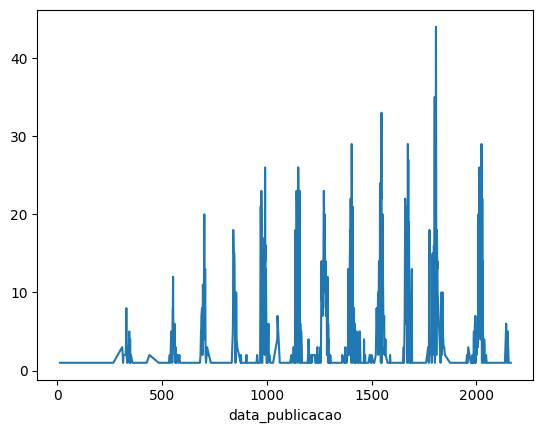

In [115]:
(pd.to_datetime(riu_df['data_publicacao'], errors='coerce').dropna() - pd.to_datetime('2020-01-01')).dt.days.value_counts().sort_index().plot()

In [174]:
tede_df['data_publicacao']

0       2021-11-29
1       2025-09-11
2       2025-09-11
3       2022-08-30
4       2025-09-19
           ...    
3949    2022-04-12
3950    2023-04-26
3951    2023-04-26
3952    2022-05-31
3953    2023-06-29
Name: data_publicacao, Length: 3954, dtype: str

<Axes: xlabel='data_publicacao'>

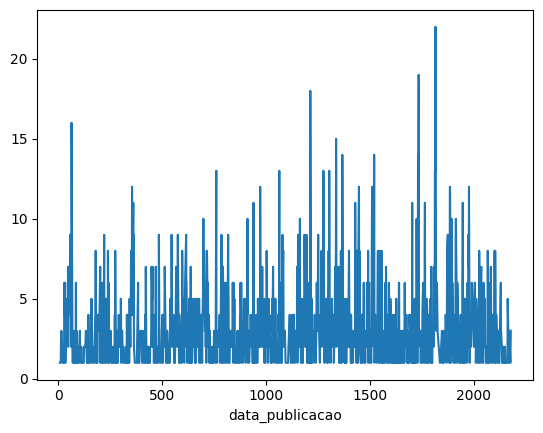

In [116]:
(pd.to_datetime(tede_df['data_publicacao'], errors='coerce').dropna() - pd.to_datetime('2020-01-01')).dt.days.value_counts().sort_index().plot()

### Juntando TEDE e RIU

#### Concatenando os dados

In [94]:
sel_cols = list(filter(lambda x: x in set(tede_df.columns) & set(riu_df.columns), tede_df.columns))

In [95]:
sel_riu_df  = riu_df[sel_cols].copy()
sel_tede_df = tede_df[sel_cols].copy()
sel_riu_df['base_original']  = 'RIU'
sel_tede_df['base_original'] = 'TEDE'

In [97]:
ufam_df = pd.concat([sel_riu_df, sel_tede_df], ignore_index=True)

#### Verificando coisas

In [170]:
def print_teses(teses_df):
    """
    Print title, abstract and keywords for each academic work in DataFrame.
    Expects columns 'titulo', 'resumo' and 'palavras_chave'.
    """
    for i in range(len(teses_df)):
        r = teses_df.iloc[i]
        print(xd.bold(r['titulo_obra']))
        print(r['resumo_obra'])
        print('')
        print('Palavras-chave:', r['palavras_chave'])
        print('')

Casos duplicados:

In [128]:
ufam_df.loc[ufam_df['uri_link'].duplicated(keep=False)]

,autoria,docente_orientador,titulo_obra,data_publicacao,instituicao_fomento,instituicao_publicadora,campus_defesa,programa_curso,tipo_trabalho,nivel_academico,total_paginas,resumo_obra,idioma_principal,uri_link,palavras_chave,base_original
3474,"Costa, Wandearlysson Araújo da","Albertino, Sônia Maria Figueiredo",Atributos químicos e físicos do solo e manejo ...,2025-09-11,CAPES - Coordenação de Aperfeiçoamento de Pess...,Universidade Federal do Amazonas,Faculdade de Ciências Agrárias,Programa de Pós-graduação em Agronomia Tropical,Dissertação,Mestrado,NaN,Neste estudo foram avaliados os efeitos do uso...,por,https://tede.ufam.edu.br/handle/tede/11315,Amazônia; CIENCIAS AGRARIAS: AGRONOMIA; Fertil...,TEDE
3475,"Costa, Wandearlysson Araújo da","Albertino, Sônia Maria Figueiredo",Atributos químicos e físicos do solo e manejo ...,2025-09-11,CNPq - Conselho Nacional de Desenvolvimento Ci...,Universidade Federal do Amazonas,Faculdade de Ciências Agrárias,Programa de Pós-graduação em Agronomia Tropical,Dissertação,Mestrado,NaN,Neste estudo foram avaliados os efeitos do uso...,por,https://tede.ufam.edu.br/handle/tede/11315,Amazônia; CIENCIAS AGRARIAS: AGRONOMIA; Fertil...,TEDE
3477,"Praia, Weslley Mesquita","Albertino, Sônia Maria Figueiredo",Banco de sementes do solo sob três coberturas ...,2025-09-19,FAPEAM - Fundação de Amparo à Pesquisa do Esta...,Universidade Federal do Amazonas,Faculdade de Ciências Agrárias,Programa de Pós-graduação em Agronomia Tropical,Dissertação,Mestrado,NaN,O manejo de plantas daninhas é essencial para ...,por,https://tede.ufam.edu.br/handle/tede/11308,CIENCIAS AGRARIAS: AGRONOMIA; Desenvolvimento ...,TEDE
3478,"Praia, Weslley Mesquita","Albertino, Sônia Maria Figueiredo",Banco de sementes do solo sob três coberturas ...,2025-09-19,CNPq - Conselho Nacional de Desenvolvimento Ci...,Universidade Federal do Amazonas,Faculdade de Ciências Agrárias,Programa de Pós-graduação em Agronomia Tropical,Dissertação,Mestrado,NaN,O manejo de plantas daninhas é essencial para ...,por,https://tede.ufam.edu.br/handle/tede/11308,CIENCIAS AGRARIAS: AGRONOMIA; Desenvolvimento ...,TEDE
3479,"Praia, Weslley Mesquita","Albertino, Sônia Maria Figueiredo",Banco de sementes do solo sob três coberturas ...,2025-09-19,CAPES - Coordenação de Aperfeiçoamento de Pess...,Universidade Federal do Amazonas,Faculdade de Ciências Agrárias,Programa de Pós-graduação em Agronomia Tropical,Dissertação,Mestrado,NaN,O manejo de plantas daninhas é essencial para ...,por,https://tede.ufam.edu.br/handle/tede/11308,CIENCIAS AGRARIAS: AGRONOMIA; Desenvolvimento ...,TEDE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7420,"Ferreira Bisneto, Pedro","Kaefer, Igor Luis",Importância epidemiológica de cobras-corais (E...,2022-06-30,FAPEAM - Fundação de Amparo à Pesquisa do Esta...,Universidade Federal do Amazonas,Instituto de Ciências Biológicas,Programa de Pós-Graduação em Zoologia,Tese,Doutorado,NaN,"Na Amazônia Brasileira, o conhecimento dos env...",por,https://tede.ufam.edu.br/handle/tede/9035,Acidente ofídico; Animais peçonhentos; Animais...,TEDE
7421,"Melo, Tomaz Nascimento de","Ribas, Camila Cherem",Padrões de uso de habitat e o efeito do alagam...,2022-04-12,USAID - US Agency for International Development,Universidade Federal do Amazonas,Centro de Ciências do Ambiente,Programa de Pós-Graduação em Zoologia,Tese,Doutorado,NaN,As várzeas são ambientes altamente produtivos ...,por,https://tede.ufam.edu.br/handle/tede/8894,Barragens hidroelétricas; CIÊNCIAS BIOLÓGICAS:...,TEDE
7422,"Melo, Tomaz Nascimento de","Ribas, Camila Cherem",Padrões de uso de habitat e o efeito do alagam...,2022-04-12,Coordenação de Aperfeiçoamento de Pessoal de N...,Universidade Federal do Amazonas,Centro de Ciências do Ambiente,Programa de Pós-Graduação em Zoologia,Tese,Doutorado,NaN,As várzeas são ambientes altamente produtivos ...,por,https://tede.ufam.edu.br/handle/tede/8894,Barragens hidroelétricas; CIÊNCIAS BIOLÓGICAS:...,TEDE
7423,"Lopes, Ana Caroliny Cer

In [130]:
len(ufam_df.drop_duplicates(subset=['uri_link']))

6909

In [135]:
len(ufam_df.drop_duplicates(subset=['uri_link', 'titulo_obra', 'autoria', 'resumo_obra', 'palavras_chave']))

6909

Explorando resumos:

In [144]:
ufam_df['resumo_obra'].fillna('').str.len().value_counts().sort_index().head(20)

resumo_obra
0      142
11       1
12      13
13      11
89       1
117      1
190      1
203      1
231      1
243      1
252      1
257      1
278      1
289      1
300      1
306      1
322      1
326      1
332      1
336      1
Name: count, dtype: int64

In [145]:
ufam_df.loc[ufam_df['resumo_obra'].fillna('').str.len() == 89, 'resumo_obra']

3466    It presents the main elements established by A...
Name: resumo_obra, dtype: str

In [121]:
ufam_df.loc[ufam_df['resumo_obra'].fillna('').str.len() == 13, 'resumo_obra']

52      Indisponível.
158     Indisponível.
170     Indisponível.
229     Indisponível.
1926    Indisponível.
1950    Indisponível.
1963    Indisponível.
2052    Indisponível.
2414    Indisponível.
5343    Indisponível.
6942    Indisponível.
Name: resumo_obra, dtype: str

In [122]:
ufam_df.loc[ufam_df['resumo_obra'].fillna('').str.len() == 12, 'resumo_obra']

4       Indisponível
66      Indisponível
75      Indisponível
87      Indisponível
93      Indisponível
193     Indisponível
196     Indisponível
241     Indisponível
770     Indisponível
1767    Indisponível
1819    Unavailable.
1937    Unavailable.
6238    Indisponível
Name: resumo_obra, dtype: str

In [124]:
ufam_df.loc[ufam_df['resumo_obra'].fillna('').str.len() == 1251, 'resumo_obra']

377     This paper analyzes the use of generative Arti...
401     This study analysed the temporal variability o...
572     This study aims to analyze the relevance of fi...
973     This thesis investigates the impact of investm...
1362    The present Final Course Work (FCW) presents a...
2273    Backpacks are the most commonly used form of c...
3262    The general objective of this work is to prese...
3451    In the information age, the big problem that i...
4048    Atualmente, a busca de estratégias para vencer...
7359    A presente pesquisa buscou fazer uma análise d...
7360    A presente pesquisa buscou fazer uma análise d...
7361    A presente pesquisa buscou fazer uma análise d...
Name: resumo_obra, dtype: str

#### Limpando

In [171]:
def remove_missing_abstracts(df, abstract_col='resumo_obra'):
    """
    Remove entries with no abstract.
    """
    
    # Hard-coded:
    missing_tags = ['Indisponível.', 'Indisponível', 'Unavailable.', 'Unavailable']
    
    sel_df = df.copy()
    sel_df.dropna(subset=abstract_col, inplace=True)
    sel_df = sel_df.loc[~sel_df[abstract_col].str.strip().isin(missing_tags)]
    
    return sel_df

In [179]:
# Limpando dados:
clean_ufam_df = ufam_df.copy()
print('# total:', len(clean_ufam_df))
# Remove duplicados:
clean_ufam_df = clean_ufam_df.drop_duplicates(subset='uri_link')
print('# deduplicados:', len(clean_ufam_df))
# Só com resumos:
clean_ufam_df = remove_missing_abstracts(clean_ufam_df)
print('# com resumos:', len(clean_ufam_df))
# Arruma resumos (sem quebra de linha):
clean_ufam_df['resumo_obra'] = clean_ufam_df['resumo_obra'].str.replace('\n', ' ')
# Change column names:
clean_ufam_df.rename({'titulo_obra': 'titulo', 'resumo_obra': 'resumo'}, axis=1, inplace=True)

# total: 7427
# deduplicados: 6909
# com resumos: 6742


In [184]:
# Salva dados limpos em CSV:
#clean_ufam_df.to_csv('../dados/dspaces/limpos/tccs-teses-dissertacoes-outros_ufam_2020-2025.csv', index=False)

## UFCG

In [69]:
def print_teses(teses_df):
    """
    Print title, abstract and keywords for each academic work in DataFrame.
    Expects columns 'titulo', 'resumo' and 'palavras_chave'.
    """
    for i in range(len(teses_df)):
        r = teses_df.iloc[i]
        print(xd.bold(r['titulo']))
        print(r['resumo'])
        print('')
        print('Palavras-chave:', r['palavras_chave'])
        print('')

In [2]:
ufcg_df = pd.read_csv('../dados/dspaces/tccs-dissertacoes-teses-2020-ufcg_v2.csv')

### Explorando

In [4]:
xe.checkMissing(ufcg_df, only_missing=False)

Colunas com valores faltantes:
                   coluna       N      %
0                 autoria     1.0   0.01
1              orientacao    26.0   0.32
2                  titulo     0.0    0.0
3   data_publicacao_texto     0.0    0.0
4                 fomento  7437.0  90.52
5              publicador     0.0    0.0
6                  campus     0.0    0.0
7          programa_curso  5484.0  66.75
8                    tipo     0.0    0.0
9         nivel_academico  8216.0  100.0
10          total_paginas  8216.0  100.0
11                 resumo    40.0   0.49
12                 idioma     0.0    0.0
13                    uri     5.0   0.06
14         palavras_chave    10.0   0.12


In [8]:
ufcg_df.loc[ufcg_df['uri'].isnull()]

,autoria,orientacao,titulo,data_publicacao_texto,fomento,publicador,campus,programa_curso,tipo,nivel_academico,total_paginas,resumo,idioma,uri,palavras_chave
1174,"MATIAS, Isabela Calixto.","DANTAS, Antônio Flávio Medeiros.","Dirofilaria immitis: incidência, fatores assoc...",2021-02-26,CNPq,Universidade Federal de Campina Grande,UFCG,PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA E SAÚDE A...,Dissertação,NaN,NaN,Esta dissertação é constituída por dois capítu...,por,NaN,Patologia animal; Parasitologia Veterinária; C...
1711,"DANTAS FILHO, Emanuel.","ALMEIDA, Hyggo Oliveira de.",Uma abordagem para gerenciamento de riscos em ...,2021-08-06,NaN,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO,Tese,NaN,NaN,Processos para gerenciamento de riscos estão p...,por,NaN,Redes bayesianas; Riscos; Projetos de software...
2709,"BARBOSA, Rodolfo dos Santos.","ROCHA, Josinaldo Lopes Araujo,",Produtos comerciais como atenuantes do estress...,2022-03-24,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,O milho é uma das culturas de maior expressivi...,por,NaN,Cultura do Milho; Estresse Hídrico; Produção A...
4217,"CAVALCANTI NETO, Jessé Souza.","ALVES, Everton Leandro Galdino.",SAP: um sistema para otimização e automação de...,2023-02-14,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Cada vez mais empresas e órgãos públicos têm e...,por,NaN,Sistema web; Procedimentos administrativos - P...
4259,"FREITAS, João Felipe da Silva.","RAMALHO, Franklin de Souza.",ConectBug: sistema para gerar e gerenciar bug ...,2023-02-14,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,"Por dia, 3739 novos aplicativos são lançados n...",por,NaN,Bug report react-native; Bug report android; A...


In [9]:
ufcg_df.loc[ufcg_df['resumo'].isnull()].head()

,autoria,orientacao,titulo,data_publicacao_texto,fomento,publicador,campus,programa_curso,tipo,nivel_academico,total_paginas,resumo,idioma,uri,palavras_chave
18,"SILVA, Lucas Henrique de Lima e.","SILVA, Thiago Emmanuel Pereira da Cunha.",Implementação do garbage collector control int...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Computação em nuvem; Cloud computing; Computac...
22,"SMANEOTO, Raoni Matos.","BRASILEIRO, Francisco Vilar.",A resilient and cloud-based batch processing s...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Batch systems; High performance computing; Clo...
34,"SOUZA, Ronan de Araújo.","SILVA, Thiago Emmanuel Pereira da Cunha.",Performance analysis between Apache Kafka and ...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Distributed systems; Apache Kafka; RabbitMQ; P...
63,"SOUZA, Beatriz Bezerra de.","GHEYI, Rohit.",Most higher mutants are useless for method-lev...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Mutation analysis; Method-level mutation oper...
79,"FREITAS, Matheus Barbosa de.","GOMES, Herman Martins.",Evaluating Karate-do movements using Kinect V2...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Karate-do; 3D motion analysis; Machine learni...


**Conclusão:** existem trabalhos sem URI e sem resumo. Ambos devem ser excluídos.

In [6]:
len(set(ufcg_df['titulo']))

8131

In [7]:
len(ufcg_df['titulo'])

8216

**Conclusão:** existem títulos duplicados. Alguns correspondem a versões diferentes do mesmo trabalho, aparentemente, sendo uma mais completa que a outra. Também existem casos com títulos padrão (e.g. Relatório de estágio).

In [16]:
xd.iskeyQ(ufcg_df.dropna(subset='uri')['uri'])

False

In [39]:
group_duplicated(ufcg_df, 'uri')

,autoria,orientacao,titulo,data_publicacao_texto,fomento,publicador,campus,programa_curso,tipo,nivel_academico,total_paginas,resumo,idioma,uri,palavras_chave
75,"SILVA, Yuri Kelvin Moura Sousa e.","MASSONI, Tiago Lima.",Introdução à Ciência da Computação: um estudo ...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,As transformações tecnológicas vividas nos dia...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Introdução à Ciência da Computação – disciplin...
93,"ARAÚJO, Victor Eduardo Borges.","RAMALHO, Franklin de Souza.",Using a thesaurus in traceability recovery bet...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Software artifacts; Bug reports; Test cases; T...
1174,"MATIAS, Isabela Calixto.","DANTAS, Antônio Flávio Medeiros.","Dirofilaria immitis: incidência, fatores assoc...",2021-02-26,CNPq,Universidade Federal de Campina Grande,UFCG,PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA E SAÚDE A...,Dissertação,NaN,NaN,Esta dissertação é constituída por dois capítu...,por,NaN,Patologia animal; Parasitologia Veterinária; C...
1711,"DANTAS FILHO, Emanuel.","ALMEIDA, Hyggo Oliveira de.",Uma abordagem para gerenciamento de riscos em ...,2021-08-06,NaN,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO,Tese,NaN,NaN,Processos para gerenciamento de riscos estão p...,por,NaN,Redes bayesianas; Riscos; Projetos de software...
2709,"BARBOSA, Rodolfo dos Santos.","ROCHA, Josinaldo Lopes Araujo,",Produtos comerciais como atenuantes do estress...,2022-03-24,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,O milho é uma das culturas de maior expressivi...,por,NaN,Cultura do Milho; Estresse Hídrico; Produção A...
4217,"CAVALCANTI NETO, Jessé Souza.","ALVES, Everton Leandro Galdino.",SAP: um sistema para otimização e automação de...,2023-02-14,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Cada vez mais empresas e órgãos públicos têm e...,por,NaN,Sistema web; Procedimentos administrativos - P...
4259,"FREITAS, João Felipe da Silva.","RAMALHO, Franklin de Souza.",ConectBug: sistema para gerar e gerenciar bug ...,2023-02-14,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,"Por dia, 3739 novos aplicativos são lançados n...",por,NaN,Bug report react-native; Bug report android; A...


In [43]:
xd.print_string_series(group_duplicated(cleaned_ufcg_df, 'resumo')['titulo'])

7495: Capitalismo Periférico na América Latina: uma análise jurídica sobre a migração trabalhista e a aplicação de legislação para proteção da dignidade do trabalhador.
7431: Capitalismo Periférico na América Latina: uma análise jurídica sobre a migração trabalhista e a aplicação de legislação para proteção da dignidade do trabalhador.
3793: Escola na feira: anteprojeto arquitetônico de escola infantil na Feira Central de Campina Grande.
3781: Escola na Feira: anteprojeto arquitetônico de escola infantil na Feira Central de Campina Grande.
5530: CINCO, seis, sete, ...: vontades de verdade sobre a dança e os corpos que dançam fora da ordem do discurso dominante.
5524: Cinco, seis, sete, ...: vontades de verdade sobre a dança e os corpos que dançam fora da ordem do discurso dominante.
4005: Prescrição cosmética individualizada na saúde da pele hiperpigmentada.
4003: Prescrição cosmética individualizada na saúde da pele hiperpigmentada.
3745: Vivências entre quatro paredes: uma revisão na

In [44]:
xd.print_string_series(group_duplicated(cleaned_ufcg_df, 'resumo')['autoria'])

7495: FERREIRA, Ana Júlia Leite.
7431: FERREIRA, Ana Júlia Leite.
3793: MENEZES, Gabriela Souza de.
3781: MENEZES, Gabriella Souza de.
5530: BEZERRA, Morgana Guedes.
5524: BEZERRA, Morgana Guedes.
4005: AQUINO, Sara Ingrid Medeiros de.
4003: AQUINO, Sara Ingrid Medeiros de.
3745: OLIVEIRA, Maria Emanuele Alves.
3744: OLIVEIRA, Maria Emanuele Alves
3742: OLIVEIRA, Maria Emanuele.
3740: OLIVEIRA, Maria Emanuelle Alves.
7666: MARTINS, William Henrique Azevedo.
7660: MARTINS, William Henrique Azevedo.
8207: SILVA, Wesley Janyel Cunha.
8205: SILVA, Wesley Janyel Cunha.
5912: CAETANO, Edmilson Júnio Medeiros.
5915: CAETANO, Edmilson Júnio Medeiros.
2679: GOMES, Allany Kaline Nascimento.
4431: GOMES, Allany Kaline Nascimento
3669: CORREIA, Marta de Medeiros.
3671: CORREIA, Marta de Medeiros.
7742: MENESES , Breno Pinheiro de.
7747: MENESES , Breno Pinheiro de.
2506: SALLES, Ana Yasha Ferreira de La.
2325: LA SALLES, Ana Yasha Ferreira de.
571: LIRA, Bruna Silveira.
3573: LIRA, Bruna Silveira.

**Conclusão:** Casos duplicados podem ter erro de grafia no título. Eliminar resumos duplicados seguramente elimina mesmos trabalhos (talvez versões diferentes).

In [34]:
ufcg_df.sort_values(by='data_publicacao_texto').drop_duplicates(subset=['titulo', 'resumo', 'palavras_chave'], keep='last')

,autoria,orientacao,titulo,data_publicacao_texto,fomento,publicador,campus,programa_curso,tipo,nivel_academico,total_paginas,resumo,idioma,uri,palavras_chave
0,"SILVA, Débora Rodrigues Azevedo.","MIRANDA, Shirley Aparecida de.",A artesania das práticas sociais e a existênci...,2020,Capes,Universidade Federal de Minas Gerais,UFMG,NaN,Dissertação,NaN,NaN,Desde as últimas décadas do século passa...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Educação -- Teses; Educação -- Relações étnica...
92,"SOUZA, Thércyo Augusto Pereira de.","AZERÊDO, Aline Figueiredo Nobrega de.",Uso de aplicativos de smartphones na medição d...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,A crescente urbanização nas cidades tem contri...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Pressão sonora - medição; Ruído aéreo em alven...
93,"ARAÚJO, Victor Eduardo Borges.","RAMALHO, Franklin de Souza.",Using a thesaurus in traceability recovery bet...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,NaN,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Software artifacts; Bug reports; Test cases; T...
94,"SILVA, Tiago Vieira de Souza Lima.","MELO, Alcília Afonso de Albuquerque.",CABO: estudos preliminares - Hotel Boutique Re...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,"O presente trabalho tem como objeto de estudo,...",por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Projeto Arquitetônico; Arquitetura Hoteleira; ...
95,"LUNA, Franklin Martins de.","MACHADO, Petruska de Araújo.",A percepção do consumidor sobre os meios de pa...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,"Em face da difusão da internet, a tecnologia p...",por,https://dspace.sti.ufcg.edu.br/handle/riufcg/1...,Pagamento Móvel; Percepção do Consumidor; Uso ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8210,"BORGES, Wiliana de Araújo.","SANTOS, Eliete Correia dos.",O ensino da leitura dialógico-discursiva na fo...,2025-12-19,NaN,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM LINGUAGEM E ENSINO,Tese,NaN,NaN,Este trabalho de tese de doutorado é um estudo...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Fontes Primárias; Licenciatura em História; Fo...
8211,"SILVA, Joice Daisyelle Bezerra.","ARAÚJO , Bruno Sérgio Vasconcelos de.",Espaços de Sobolev com pesos e problemas de ev...,2025-12-19,Capes,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM MATEMÁTICA,Dissertação,NaN,NaN,"Nopresentetrabalho,utilizamosaTeoriadeSemigrup...",por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Espaços de Sobolev com peso; Problemas degener...
8212,"NUNES, Juliana Pessoa.","SERRES, Georgina Karla de Freitas.",Projeto e análise de uma chave bootstrapped pa...,2025-12-19,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Este trabalho apresenta o projeto e análise de...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Circuito de Amostragem; Bootstrapping; Lineari...
8213,"ALMEIDA, Evanilson Souza de.","SOARES, Lauriane Almeida dos Anjos.",Fertilizante à base de fungos micorrizos no cu...,2025-12-19,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,"No Nordeste do Brasil, a cotonicultura é uma a...",por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Cotonicultura; Cotton farming; Condutividade e...


In [35]:
len(ufcg_df)

8216

In [28]:
ufcg_df['tipo'].value_counts(dropna=False)

tipo
Trabalho de Conclusão de Curso    5476
Dissertação                       2044
Tese                               696
Name: count, dtype: int64

In [66]:
ufcg_df['data_publicacao_texto'].value_counts().head(20)

data_publicacao_texto
2021          174
2023          161
2022          150
2020          144
2024           89
2023-02-14     86
2024-05-15     74
2022-09-02     63
2025           55
2023-06-28     51
2023-11-08     51
2021-05-25     48
2023-11-06     44
2023-11-17     44
2022-08-25     43
2023-02-09     41
2023-11-07     41
2021-10-20     39
2023-02-10     39
2023-02-08     38
Name: count, dtype: int64

In [73]:
ufcg_df['resumo'].fillna('').str.len().value_counts().sort_index().head(20)

resumo
0      40
147     1
157     1
163     1
165     2
169     1
179     1
180     1
207     1
212     1
213     1
225     1
226     1
227     1
235     1
236     1
243     1
256     1
262     1
267     1
Name: count, dtype: int64

### Limpeza

In [59]:
# Inicia limpeza:
cleaned_ufcg_df = ufcg_df.copy()
print('# trabalhos total:', len(cleaned_ufcg_df))
# Elimina URI faltando:
cleaned_ufcg_df = cleaned_ufcg_df.loc[~cleaned_ufcg_df['uri'].isnull()]
print('# com URI:', len(cleaned_ufcg_df))
# Elimina resumo Faltando:
cleaned_ufcg_df = cleaned_ufcg_df.loc[~cleaned_ufcg_df['resumo'].isnull()]
print('# com resumo:', len(cleaned_ufcg_df))
# Coloca resumo numa linha só:
cleaned_ufcg_df['resumo'] = cleaned_ufcg_df['resumo'].str.replace('\r\n', ' ').str.replace('\n', ' ')
# Elimina resumos duplicados, ficando com versão mais recente:
cleaned_ufcg_df = cleaned_ufcg_df.sort_values(by='data_publicacao_texto').drop_duplicates(subset='resumo', keep='last')
print('# sem resumos duplicados:', len(cleaned_ufcg_df))

# trabalhos total: 8216
# com URI: 8211
# com resumo: 8171
# sem resumos duplicados: 8135


In [74]:
# Salva dados limpos em CSV:
#cleaned_ufcg_df.to_csv('../dados/dspaces/limpos/tccs-teses-dissertacoes_ufcg_2020-2025.csv', index=False)

## Selecionando uma amostra

In [76]:
clean_df = pd.read_csv('../dados/dspaces/limpos/tccs-teses-dissertacoes_ufcg_2020-2025.csv')
# Arruma palavras-chave (NaN - > ''):
clean_df['palavras_chave'] = clean_df['palavras_chave'].fillna('')

In [77]:
llm_frac = 0.10
llm_true_conversion = 0.80
#n_target = int(500 / 13)
#n_input  = len(clean_ufam_df)
#n_togo   = n_target / llm_true_conversion / llm_frac
sample_frac = 0.07 #n_togo / n_input
print('Vamos selecionar {:.3f} dos trabalhos presentes nas bases bibliográficas.'.format(sample_frac))

Vamos selecionar 0.070 dos trabalhos presentes nas bases bibliográficas.


In [78]:
#sample_df = clean_df.sample(frac=0.07, random_state=68997) # UFAM
sample_df = clean_df.sample(frac=0.07, random_state=1478) # UFCG
len(sample_df)

569

In [79]:
# Save to CSV:
#sample_df.to_csv('../dados/dspaces/samples/tccs-teses-dissertacoes_ufcg_2020-2025_n569_s01.csv', index=False)

In [80]:
sample_df

,autoria,orientacao,titulo,data_publicacao_texto,fomento,publicador,campus,programa_curso,tipo,nivel_academico,total_paginas,resumo,idioma,uri,palavras_chave
3063,"BATISTA, Lucas Alexander Nunes.","NASCIMENTO, Celso Gestermeier do.",“Eu sou negro antes de ser um homem”: os sujei...,2022-08,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,A monografia analisa os discursos que tentam s...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/3...,Cinema e história; Medicine for melancholy - f...
2980,"BARBOZA, Weiller Felipe Chaves.","VELÁSQUEZ, Marco Antonio Lázaro.",On spacelike immersions in locally symmetric s...,2022-06-21,Capes,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM MATEMÁTICA,Tese,NaN,NaN,Na primeira parte desta tese estudamos a geome...,eng,https://dspace.sti.ufcg.edu.br/handle/riufcg/3...,Geometria diferencial; Espaços localmente simé...
122,"FERREIRA, Mariana Nogueira.","FIGUEIREDO, Carla Pedrosa de.",Análise acerca da eficácia das políticas públi...,2020,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,A infância e adolescência são etapas de formaç...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/1...,Crianças e Adolescentes; Tráfico de Drogas; Tr...
5655,"GOMES, Filipe Tawã.","NOGUEIRA, Virgínia de Fátima Bezerra.",Integração do geoprocessamento na gestão ambie...,2023-12-04,NaN,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM SISTEMAS AGROINDUSTRIAIS,Dissertação,NaN,NaN,"Nesta pesquisa, realizou-se uma revisão sistem...",por,https://dspace.sti.ufcg.edu.br/handle/riufcg/4...,Geoprocessamento; Geoprocessing; Gestão ambien...
5195,"LIMA, Vitória Pereira Cardoso de.","OLIVEIRA, Yonara Monique da Costa.",Saúde mental de pessoas com Diabetes mellitus:...,2023-10-25,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,A diabetes mellitus é um importante e crescent...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/3...,Diabetes mellitus; Saúde mental; Diabetes mell...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840,"MORAIS, Gisely Patricia de Souza.","FLORENCIO, José Herbertt Neves.",O ensino da flexão de número dos substantivos ...,2024-10-29,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Este trabalho tem como objetivo propor possibi...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/3...,Língua Portuguesa – Estudo e Ensino; Flexão de...
2253,"SILVA, Noélia Nunes da.","GUERRA SOBRINHO, Lemuel Dourado.",Entre (des)crer e (des)obeceder: uma análise d...,2021-12-16,Capes,Universidade Federal de Campina Grande,UFCG,PÓS-GRADUAÇÃO EM CIÊNCIAS SOCIAIS,Tese,NaN,NaN,Este trabalho tem o objetivo de compreender co...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Assembleia de Deus; Tradição; Desvio; Racional...
1611,"RODRIGUES, Laécio Henrique Mauriz.","SOUZA, Ronimack Trajano de.",Relatório de estágio supervisionado: Solar Nobre.,2021-06-07,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Esse trabalho relata as atividades realiz...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Estágio em Engenharia Elétrica; Solar Nobre; E...
2433,"FIGUEIREDO, Diógenes Lopes de.","LEAL, Marilia Daniella Freitas Oliveira.",Uma análise jurídica do procedimento da “alta ...,2022,NaN,Universidade Federal de Campina Grande,UFCG,NaN,Trabalho de Conclusão de Curso,NaN,NaN,Este trabalho tem como objeto de estudo a anál...,por,https://dspace.sti.ufcg.edu.br/handle/riufcg/2...,Previdência Social.; Auxílio por incapacidade ...
